In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import geopandas as gpd

pd.set_option("display.max_columns", None)

# Gráficos finales para informe técnico y dashboard ejecutivo

Este notebook reúne las visualizaciones finales seleccionadas para el informe técnico y el dashboard ejecutivo del proyecto agroclimático multicultivo.

El objetivo es generar gráficos limpios, consistentes y exportables en alta calidad para su uso en:

- informe técnico,
- dashboard ejecutivo,
- presentación final,
- y portfolio profesional.

## KPIs comparativos de modelos finales

Se comparan las principales métricas predictivas obtenidas para los modelos finales de soja, maíz y trigo.

Las métricas consideradas son:

- R²
- RMSE
- MAE

In [2]:
kpis = pd.DataFrame({

    "Cultivo": [
        "Soja",
        "Maíz",
        "Trigo"
    ],

    "Modelo": [
        "RF + VPD",
        "RF ENSO + VPD",
        "RF Eventos Extremos"
    ],

    "R2": [
        0.930,
        0.901,
        0.919
    ],

    "RMSE": [
        214.27,
        699.50,
        285.40
    ],

    "MAE": [
        np.nan,
        490.04,
        205.94
    ]

})

In [3]:
kpis

,Cultivo,Modelo,R2,RMSE,MAE
0,Soja,RF + VPD,0.930,214.27,NaN
1,Maíz,RF ENSO + VPD,0.901,699.50,490.04
2,Trigo,RF Eventos Extremos,0.919,285.40,205.94


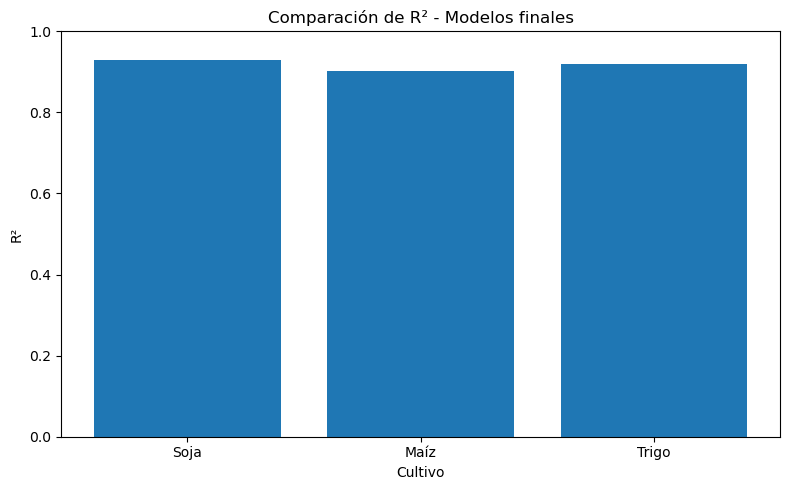

In [4]:
plt.figure(figsize=(8,5))

plt.bar(
    kpis["Cultivo"],
    kpis["R2"]
)

plt.title("Comparación de R² - Modelos finales")
plt.xlabel("Cultivo")
plt.ylabel("R²")

plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "../Dashboard/kpi_r2_modelos_finales.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Heatmap multicultivo de sensibilidad agroclimática

Se representa la sensibilidad relativa de soja, maíz y trigo frente a distintos factores agroclimáticos y atmosféricos.

El objetivo es visualizar diferencias en:

- sensibilidad hídrica,
- estrés evaporativo,
- estabilidad temporal,
- y vulnerabilidad frente a eventos extremos.

In [5]:
import seaborn as sns

In [6]:
sensibilidad_multicultivo = pd.DataFrame({

    "Factor": [

        "Estrés hídrico",
        "Estrés evaporativo",
        "Eventos extremos",
        "Estabilidad temporal",
        "Complejidad atmosférica"

    ],

    "Soja": [
        7,
        6,
        6,
        8,
        5
    ],

    "Maíz": [
        9,
        8,
        8,
        6,
        7
    ],

    "Trigo": [
        6,
        10,
        10,
        4,
        10
    ]

})

In [7]:
datos_heatmap = sensibilidad_multicultivo.set_index(
    "Factor"
).T

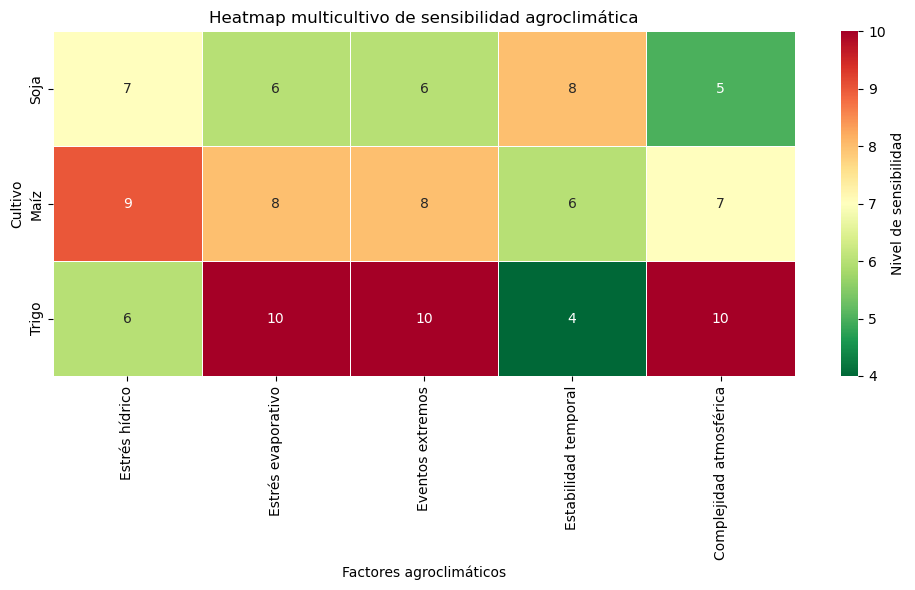

In [8]:
plt.figure(figsize=(10,6))

sns.heatmap(

    datos_heatmap,

    annot=True,
    cmap="RdYlGn_r",

    linewidths=0.5,
    cbar_kws={
        "label": "Nivel de sensibilidad"
    }

)

plt.title(
    "Heatmap multicultivo de sensibilidad agroclimática"
)

plt.xlabel("Factores agroclimáticos")
plt.ylabel("Cultivo")

plt.tight_layout()

plt.savefig(
    "../Dashboard/heatmap_multicultivo.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Comparación multicultivo de sensibilidad agroclimática

Se comparan los perfiles de sensibilidad agroclimática de soja, maíz y trigo frente a distintos factores climáticos.

Este gráfico permite observar diferencias estructurales entre cultivos y visualizar qué factores dominan en cada sistema agrícola.

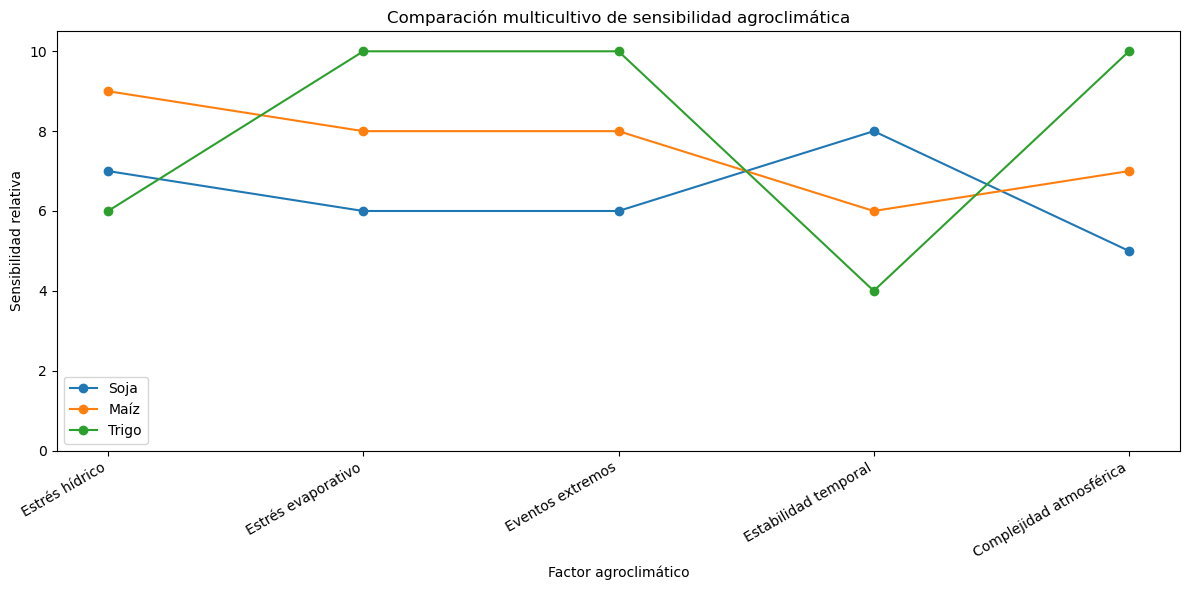

In [9]:
plt.figure(figsize=(12,6))

plt.plot(
    sensibilidad_multicultivo["Factor"],
    sensibilidad_multicultivo["Soja"],
    marker="o",
    label="Soja"
)

plt.plot(
    sensibilidad_multicultivo["Factor"],
    sensibilidad_multicultivo["Maíz"],
    marker="o",
    label="Maíz"
)

plt.plot(
    sensibilidad_multicultivo["Factor"],
    sensibilidad_multicultivo["Trigo"],
    marker="o",
    label="Trigo"
)

plt.title("Comparación multicultivo de sensibilidad agroclimática")
plt.xlabel("Factor agroclimático")
plt.ylabel("Sensibilidad relativa")

plt.xticks(rotation=30, ha="right")
plt.ylim(0, 10.5)

plt.legend()
plt.tight_layout()

plt.savefig(
    "../Dashboard/comparacion_multicultivo_sensibilidad.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Campañas extremas destacadas

Se representan campañas agrícolas críticas identificadas durante el análisis agroclimático.

Estas campañas estuvieron asociadas a sequías, estrés evaporativo, calor extremo y condiciones fuera del régimen climático habitual.

In [10]:
campañas_extremas = pd.DataFrame({

    "Campaña": [
        "Maíz 2017/18",
        "Maíz 2022/23",
        "Trigo 2021/22",
        "Trigo 2022/23"
    ],

    "Intensidad_extrema": [
        8,
        10,
        9,
        10
    ]

})

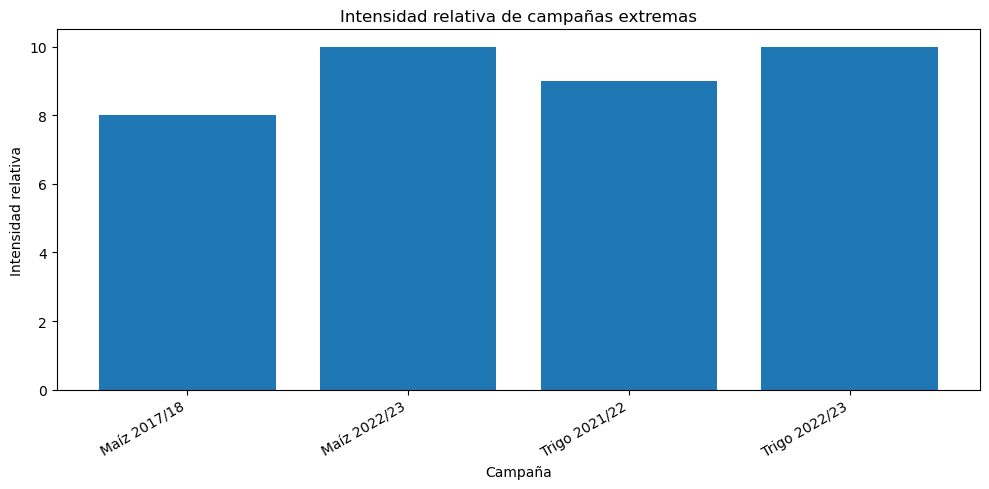

In [11]:
plt.figure(figsize=(10,5))

plt.bar(
    campañas_extremas["Campaña"],
    campañas_extremas["Intensidad_extrema"]
)

plt.title("Intensidad relativa de campañas extremas")
plt.xlabel("Campaña")
plt.ylabel("Intensidad relativa")

plt.ylim(0, 10.5)

plt.xticks(rotation=30, ha="right")

plt.tight_layout()

plt.savefig(
    "../Dashboard/intensidad_campañas_extremas.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## Mapa agroambiental del sur de Santa Fe

Se incorpora una visualización geoespacial del sur de Santa Fe con el objetivo de representar la heterogeneidad territorial y agroambiental de la región agrícola principal del proyecto.

Este mapa permite complementar el análisis agroclimático con una dimensión espacial basada en categorías agroambientales.

In [12]:
import geopandas as gpd
import matplotlib.pyplot as plt

In [13]:
# Cargar capa agroambiental

mapa_arg = gpd.read_file(
    r"C:\Users\aylen\Clima-Inteligente-SantaFe\Data\Suelos\result.gpkg"
)

C:\Users\aylen\anaconda3\envs\clima\Lib\site-packages\pyogrio\raw.py:200: RuntimeWarning: GPKG: unrecognized user_version=0x00000000 (0) on 'C:\Users\aylen\Clima-Inteligente-SantaFe\Data\Suelos\result.gpkg'
  return ogr_read(


In [14]:
# Renombrar columnas para trabajar más claro

mapa_arg = mapa_arg.rename(columns={

    "gridcode": "clase_agroambiental",
    "cpa": "categoria_agroambiental",
    "area": "area"

})

In [15]:
# Filtrar sur de Santa Fe

sur_sf = mapa_arg.cx[
    -62.9:-58.8,
    -34.4:-31.0
]

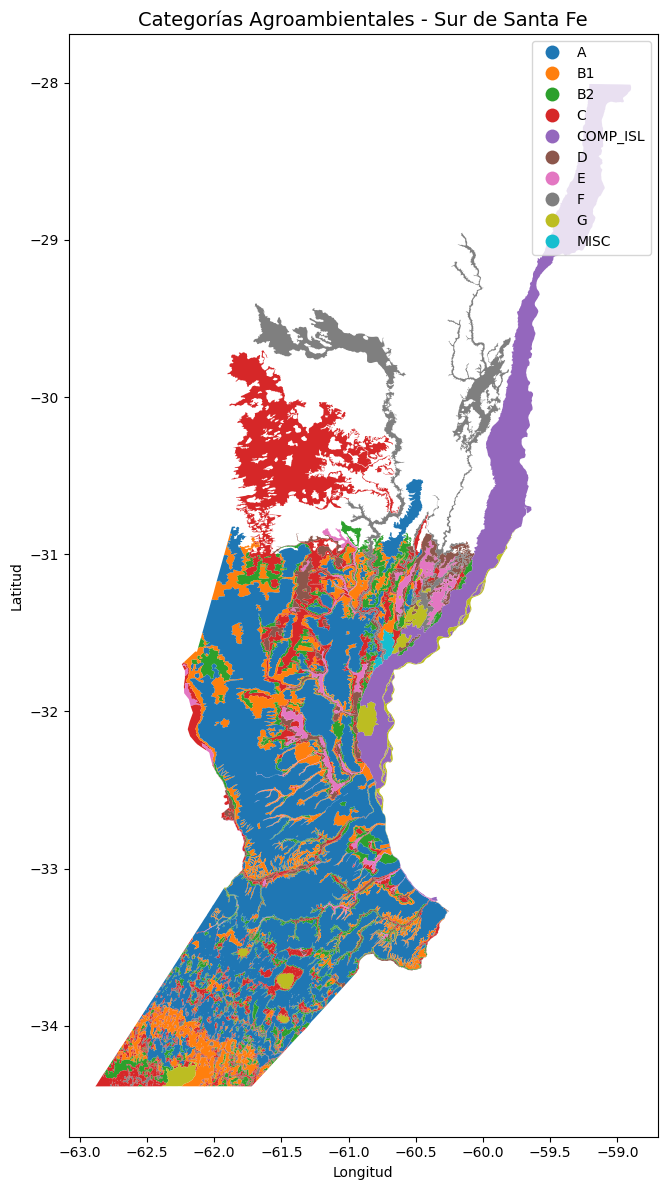

In [16]:
# Crear mapa

fig, ax = plt.subplots(figsize=(10,12))

sur_sf.plot(
    column="categoria_agroambiental",
    categorical=True,
    legend=True,
    ax=ax
)

ax.set_title(
    "Categorías Agroambientales - Sur de Santa Fe",
    fontsize=14
)

ax.set_xlabel("Longitud")
ax.set_ylabel("Latitud")

plt.tight_layout()

plt.savefig(
    "../Dashboard/mapa_agroambiental_sur_santafe.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()